--- Data Loading and Preprocessing ---
[Winter      ] Loaded 'data_winter.csv' | Train: 17775 samples (SMOTE) | Test: 2529 samples
[Summer      ] Loaded 'data_summer.csv' | Train: 26604 samples (SMOTE) | Test: 2928 samples
[Monsoon     ] Loaded 'data_monsoon.csv' | Train: 24753 samples (SMOTE) | Test: 3175 samples
[Post_monsoon] Loaded 'data_post_monsoon.csv' | Train: 13272 samples (SMOTE) | Test: 1560 samples

Data preparation complete.

--- Training Decision Tree Models Across Seasons ---

Training Decision Tree for: [WINTER]
  Training complete. Tree depth: 32 | Leaves: 1589

Training Decision Tree for: [SUMMER]
  Training complete. Tree depth: 37 | Leaves: 2882

Training Decision Tree for: [MONSOON]
  Training complete. Tree depth: 30 | Leaves: 2429

Training Decision Tree for: [POST_MONSOON]
  Training complete. Tree depth: 35 | Leaves: 1162

Decision Tree training complete.

--- Evaluating Within-Season Test Performance ---

=== Decision Tree: Within-Season Baseline (E1) ===
    

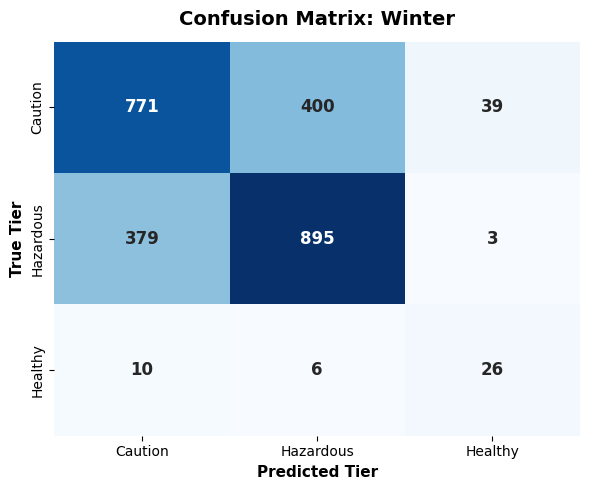

Saved: results/visualizations/decision_tree/cm_winter.png


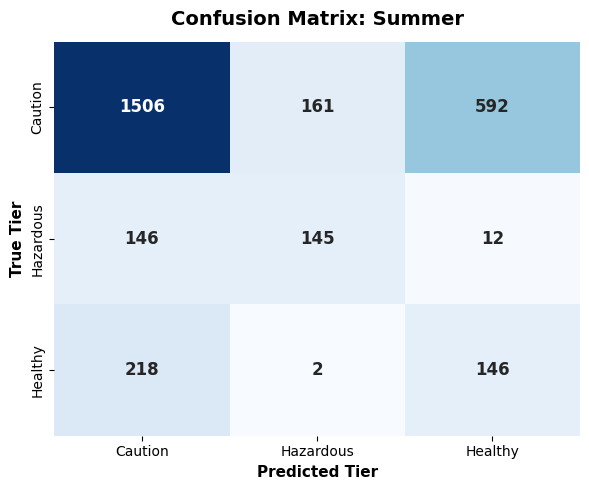

Saved: results/visualizations/decision_tree/cm_summer.png


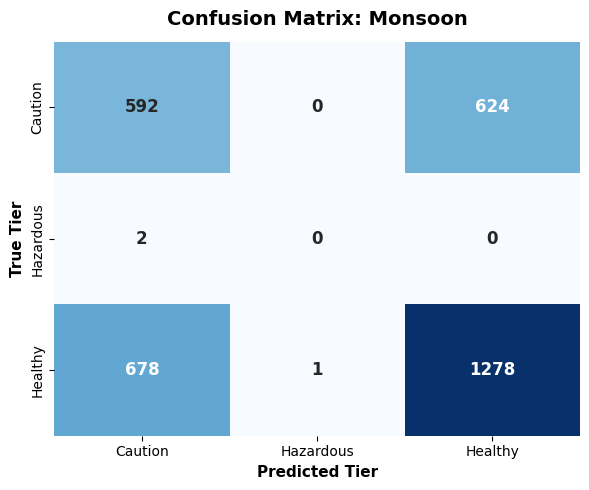

Saved: results/visualizations/decision_tree/cm_monsoon.png


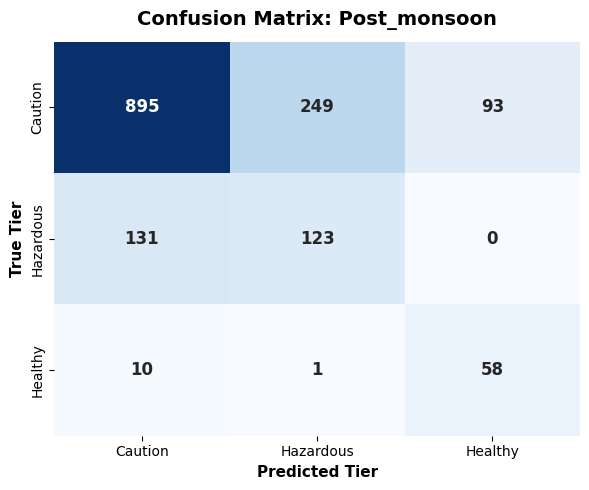

Saved: results/visualizations/decision_tree/cm_post_monsoon.png

--- Generating Feature Importance ---


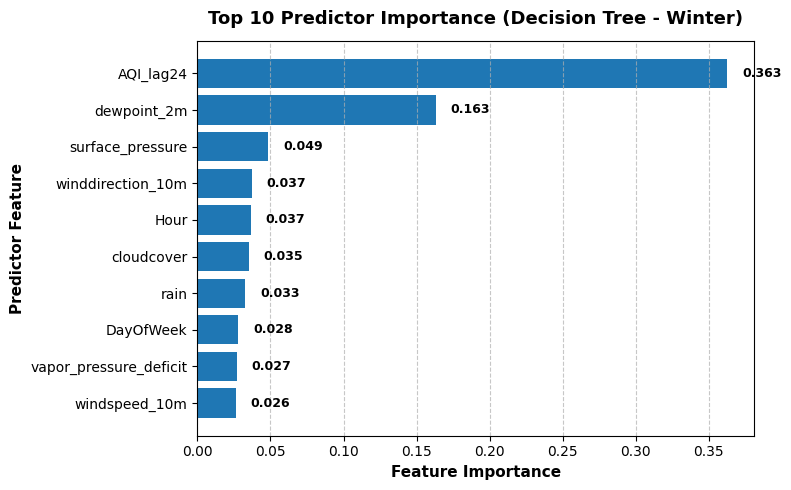

Saved: results/visualizations/decision_tree/feature_importance_winter.png


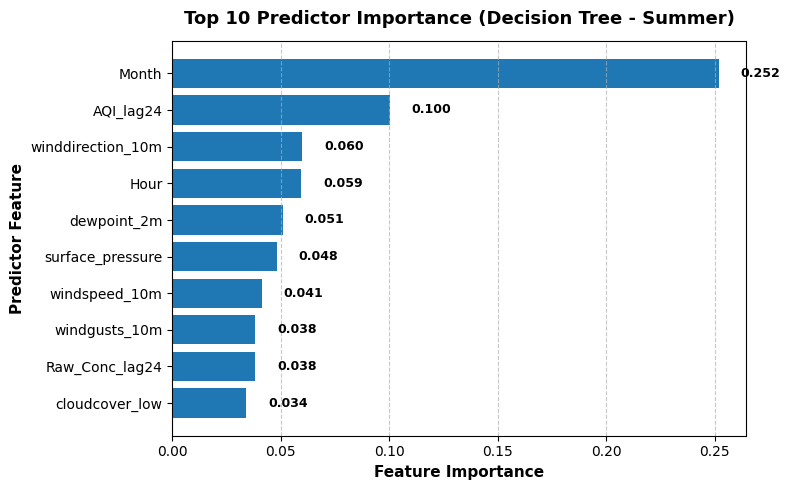

Saved: results/visualizations/decision_tree/feature_importance_summer.png


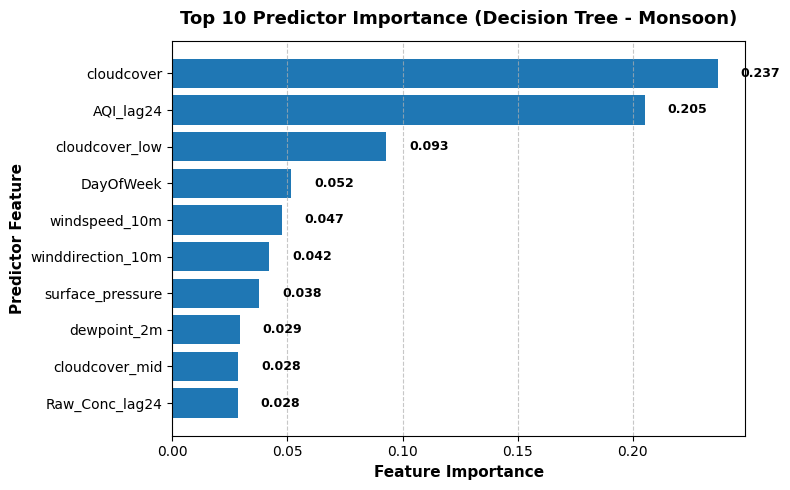

Saved: results/visualizations/decision_tree/feature_importance_monsoon.png


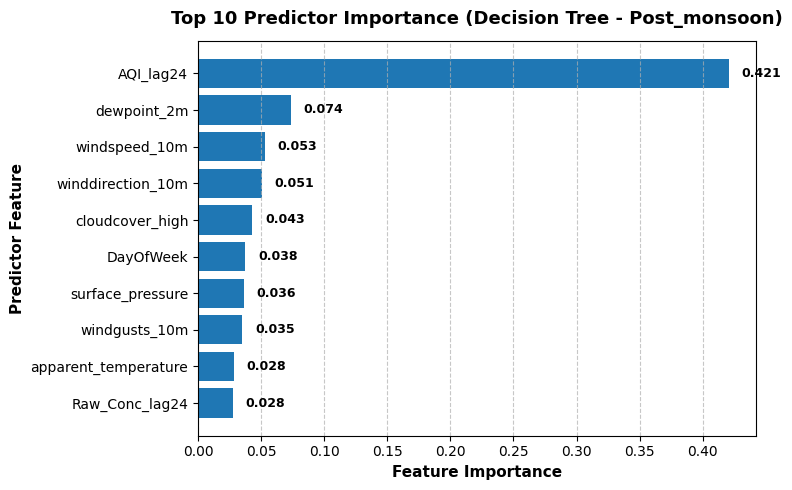

Saved: results/visualizations/decision_tree/feature_importance_post_monsoon.png

=== All Decision Tree outputs generated successfully ===


In [ ]:
# ==========================================
# CELL 1: Data Loading, Splitting & Preprocessing
# ==========================================
import os
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
import warnings

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')


# ==========================================
# 1. Define Predictors & Target
# ==========================================

predictors = [
    'AQI_lag24',
    'Raw_Conc_lag24',
    'Hour',
    'Month',
    'DayOfWeek',
    'temperature_2m',
    'relativehumidity_2m',
    'dewpoint_2m',
    'apparent_temperature',
    'precipitation',
    'rain',
    'surface_pressure',
    'cloudcover',
    'cloudcover_low',
    'cloudcover_mid',
    'cloudcover_high',
    'windspeed_10m',
    'winddirection_10m',
    'windgusts_10m',
    'et0_fao_evapotranspiration',
    'vapor_pressure_deficit',
    'shortwave_radiation',
    'direct_radiation',
    'diffuse_radiation',
    'weathercode'
]

target = 'Hazard_Tier'

seasons = [
    'winter',
    'summer',
    'monsoon',
    'post_monsoon'
]


# Dictionary to hold processed data
processed_data = {}

print("--- Data Loading and Preprocessing ---")


# ==========================================
# 2. Load and Prepare Each Seasonal Dataset
# ==========================================

for season in seasons:

    possible_names = [
        f"{season}.csv",
        f"data_{season}.csv",
        f"dhaka_{season}.csv"
    ]

    file_path = None

    for name in possible_names:
        if os.path.exists(name):
            file_path = name
            break

    if file_path is None:
        raise FileNotFoundError(
            f"Could not find CSV for '{season}'. "
            f"Expected one of: {possible_names}"
        )

    df = pd.read_csv(file_path)

    # ------------------------------------------
    # 80/20 time-based split
    # ------------------------------------------
    split_idx = int(len(df) * 0.8)

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    # ------------------------------------------
    # Select X and y
    # ------------------------------------------
    X_train_raw = train_df[predictors]
    y_train_raw = train_df[target]

    X_test_raw = test_df[predictors]
    y_test_raw = test_df[target]

    # ------------------------------------------
    # Decision Trees DO NOT require scaling
    # ------------------------------------------

    X_train = X_train_raw.copy()
    X_test = X_test_raw.copy()

    # ------------------------------------------
    # SMOTE only on training data
    # ------------------------------------------
    smote = SMOTE(random_state=42)

    X_train_res, y_train_res = smote.fit_resample(
        X_train,
        y_train_raw
    )

    # ------------------------------------------
    # Store processed data
    # ------------------------------------------
    processed_data[season] = {
        'X_train': X_train_res,
        'y_train': y_train_res,
        'X_test': X_test,
        'y_test': y_test_raw
    }

    print(
        f"[{season.capitalize():<12}] "
        f"Loaded '{file_path}' | "
        f"Train: {X_train_res.shape[0]} samples (SMOTE) | "
        f"Test: {X_test.shape[0]} samples"
    )


print("\nData preparation complete.\n")


# ==========================================
# CELL 2: Train Decision Tree Models
# ==========================================

trained_models = {}

print("--- Training Decision Tree Models Across Seasons ---")


for season in seasons:

    print(f"\nTraining Decision Tree for: [{season.upper()}]")

    X_tr = processed_data[season]['X_train']
    y_tr = processed_data[season]['y_train']

    # ------------------------------------------
    # Decision Tree
    # ------------------------------------------
    model = DecisionTreeClassifier(
        random_state=42
    )

    model.fit(X_tr, y_tr)

    trained_models[season] = model

    print(
        f"  Training complete."
        f" Tree depth: {model.get_depth()}"
        f" | Leaves: {model.get_n_leaves()}"
    )


print("\nDecision Tree training complete.\n")


# ==========================================
# CELL 3: Evaluation
# ==========================================

def calc_gmean(y_true, y_pred):

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    recalls = [
        report[cls]['recall']
        for cls in report
        if cls not in [
            'accuracy',
            'macro avg',
            'weighted avg'
        ]
    ]

    return np.exp(
        np.mean(
            np.log(
                np.maximum(recalls, 1e-5)
            )
        )
    )


results = []
detailed_reports = []
evaluation_logs = {}


print("--- Evaluating Within-Season Test Performance ---")


for season in seasons:

    model = trained_models[season]

    X_te = processed_data[season]['X_test']
    y_te = processed_data[season]['y_test']

    # ------------------------------------------
    # Predictions
    # ------------------------------------------
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)

    # ------------------------------------------
    # Metrics
    # ------------------------------------------
    macro_f1 = f1_score(
        y_te,
        y_pred,
        average='macro'
    )

    g_mean = calc_gmean(
        y_te,
        y_pred
    )

    try:

        macro_auc = roc_auc_score(
            y_te,
            y_proba,
            multi_class='ovr',
            average='macro'
        )

    except ValueError:

        macro_auc = np.nan

    # ------------------------------------------
    # Confusion Matrix
    # ------------------------------------------
    cm = confusion_matrix(
        y_te,
        y_pred
    )

    # ------------------------------------------
    # Classification Report
    # ------------------------------------------
    report_dict = classification_report(
        y_te,
        y_pred,
        output_dict=True
    )

    # ------------------------------------------
    # Save evaluation information
    # ------------------------------------------
    evaluation_logs[season] = {
        'y_true': y_te,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'cm': cm,
        'report': classification_report(
            y_te,
            y_pred
        )
    }

    # ------------------------------------------
    # High-level metrics
    # ------------------------------------------
    results.append({
        'Model': 'Decision Tree',
        'Season': season.capitalize(),
        'Macro F1': round(macro_f1, 4),
        'Macro AUC': round(macro_auc, 4),
        'G-Mean': round(g_mean, 4)
    })

    # ------------------------------------------
    # Detailed metrics
    # ------------------------------------------
    for cls_name, metrics in report_dict.items():

        if isinstance(metrics, dict):

            detailed_reports.append({
                'Season': season.capitalize(),
                'Class': cls_name,
                'Precision': round(
                    metrics['precision'],
                    4
                ),
                'Recall': round(
                    metrics['recall'],
                    4
                ),
                'F1-Score': round(
                    metrics['f1-score'],
                    4
                ),
                'Support': int(
                    metrics['support']
                )
            })


# ==========================================
# CELL 4: Save Evaluation Results
# ==========================================

tables_dir = os.path.join(
    "results",
    "tables"
)

os.makedirs(
    tables_dir,
    exist_ok=True
)


# Summary table
results_df = pd.DataFrame(results)

summary_csv_path = os.path.join(
    tables_dir,
    "decision_tree_e1.csv"
)

results_df.to_csv(
    summary_csv_path,
    index=False
)


# Detailed table
detailed_df = pd.DataFrame(
    detailed_reports
)

detailed_csv_path = os.path.join(
    tables_dir,
    "decision_tree_e1_detailed.csv"
)

detailed_df.to_csv(
    detailed_csv_path,
    index=False
)


print("\n=== Decision Tree: Within-Season Baseline (E1) ===")

print(
    results_df.to_string(
        index=False
    )
)

print(
    f"\n[SUCCESS] Saved summary to: "
    f"{summary_csv_path}"
)

print(
    f"[SUCCESS] Saved detailed results to: "
    f"{detailed_csv_path}"
)


# ==========================================
# CELL 5: Confusion Matrices
# ==========================================

output_dir = os.path.join(
    "results",
    "visualizations",
    "decision_tree"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


print("\n--- Generating Confusion Matrices ---")


for season in seasons:

    plt.figure(
        figsize=(6, 5)
    )

    cm = evaluation_logs[season]['cm']

    labels = sorted(
        list(
            set(
                evaluation_logs[season]['y_true']
            )
        )
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
        annot_kws={
            "size": 12,
            "weight": "bold"
        }
    )

    plt.title(
        f'Confusion Matrix: '
        f'{season.capitalize()}',
        fontsize=14,
        fontweight='bold',
        pad=12
    )

    plt.xlabel(
        'Predicted Tier',
        fontsize=11,
        fontweight='bold'
    )

    plt.ylabel(
        'True Tier',
        fontsize=11,
        fontweight='bold'
    )

    plt.tight_layout()

    file_path = os.path.join(
        output_dir,
        f"cm_{season}.png"
    )

    plt.savefig(
        file_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f"Saved: {file_path}"
    )


# ==========================================
# CELL 6: Decision Tree Feature Importance
# ==========================================

print("\n--- Generating Feature Importance ---")


for season in seasons:

    model = trained_models[season]

    importances = model.feature_importances_

    top_idx = np.argsort(
        importances
    )[-10:]

    plt.figure(
        figsize=(8, 5)
    )

    bars = plt.barh(
        np.array(predictors)[top_idx],
        importances[top_idx]
    )

    plt.title(
        f'Top 10 Predictor Importance '
        f'(Decision Tree - {season.capitalize()})',
        fontsize=13,
        fontweight='bold',
        pad=12
    )

    plt.xlabel(
        'Feature Importance',
        fontsize=11,
        fontweight='bold'
    )

    plt.ylabel(
        'Predictor Feature',
        fontsize=11,
        fontweight='bold'
    )

    plt.grid(
        axis='x',
        linestyle='--',
        alpha=0.7
    )

    for bar in bars:

        width = bar.get_width()

        plt.text(
            width + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{width:.3f}',
            va='center',
            ha='left',
            fontsize=9,
            fontweight='bold'
        )

    plt.tight_layout()

    feat_file_path = os.path.join(
        output_dir,
        f"feature_importance_{season}.png"
    )

    plt.savefig(
        feat_file_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f"Saved: {feat_file_path}"
    )


print("\n=== All Decision Tree outputs generated successfully ===")